# 🌽 US Corn Market EDA — Analytical Validation & Insight Mining

This notebook validates that the ELT pipeline produced a coherent analytical table and performs **EDA (Exploratory Data Analysis)** on it:
- Validate engineered features behave plausibly (agronomy/economics hypotheses)
- Identify outlier years (e.g., 1988, 2012)
- Diagnose time effects (trend, regime shifts, stationarity considerations)
- Check multicollinearity

> Note: This EDA is **not** a re-implementation of dbt tests or pipeline quality gates. We focus here on analytical validity and insight extraction evaluating **behavior, relationships, and modeling readiness**.

---

## **Final Dataset — Column Dictionary**
The dataset represents the final analytical table ingested from our BigQuery Data Warehouse. It aggregates annual US corn metrics (1973–2024).

| Feature Category | Column | Definition |
|:---|:---|:---|
| **Time** | `year` | Marketing Year (1973–2024) |
| **Production** | `planted_acres` | Total US planted area (thousand acres) |
| | `harvested_acres` | Total US harvested area (thousand acres) |
| | `actual_yield` | Realized crop yield (bushels/acre) |
| | `production` | Total volume produced (million bushels) |
| **Supply & Demand** | `exports` / `imports` | International trade flows (million bushels) |
| | `total_supply` | Total available corn (million bushels). Aggregates production, imports, and beginning stocks: carryover from the previous year |
| | `all_dom_use` | Domestic use (million bushels) |
| | `total_usage` | Aggregates domestic use and exports (million bushels) |
| | `ending_stocks` | Leftover inventory at year-end (million bushels) |
| | `stock_to_use_ratio` | Inventory scarcity metric calculated as `Ending Stocks / Usage` |
| **Market** | `price_per_bushel` | Average price (USD) received in November: harvest-month price point |
| **Weather / Bio** | `planting_50_pct_doy` | Day of Year (1–365) national crop reached 50% completion |
| | `temp_stress_july_count` | Spatially-weighted count of days with national average temperatures $>35°C$ during the silking window (60–90 days post-50% planting) |
| | `rainfall_effectiveness_index` | Rainfall effectiveness ratio. Calculated as `(Cumulative Rain Mar–Jun) / Planting DOY`. Captures the utility of spring moisture |
| | `post_pollination_rain` | Reproductive phase rainfall (inches). Cumulative rainfall during the 60–90 day window post-planting after 50% planting |
| | `avg_condition_pollination_index` | Weighted Crop Health Score. A numerical index (1–5 scale) of USDA ratings during the pollination window |

## Environment Setup
This section installs and imports the libraries used for data handling, visualization, and statistical diagnostics.  

In [1]:
!pip -q install missingno statsmodels scipy

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats
from IPython.display import display

from google.cloud import bigquery
from google.colab import auth

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## Load the Final Analytical Table from BigQuery

This notebook connects directly to **BigQuery** and pulls the final analytical table (dbt mart output).  
This ensures EDA reflects the **single source of truth** produced by the ELT pipeline.


In [3]:
try:
    auth.authenticate_user()
    print("✅ Authentication Successful")
except Exception as e:
    print(f"⚠️ Authentication Failed: {e}")

PROJECT_ID = 'us-corn-data'
DATASET_ID = 'us_corn_data_transformed'
TABLE_NAME = 'mart_corn_model_data'

client = bigquery.Client(project=PROJECT_ID)

query = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
    ORDER BY year ASC
"""

try:
    df = client.query(query).to_dataframe()
    print(f"✅ Data Loaded: {df.shape[0]} Rows, {df.shape[1]} Columns\n")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    df = pd.DataFrame()

✅ Authentication Successful
✅ Data Loaded: 52 Rows, 18 Columns



In [4]:
df

,year,planted_acres,harvested_acres,actual_yield,production,exports,imports,total_supply,all_dom_use,total_usage,ending_stocks,stock_to_use_ratio,price_per_bushel,avg_condition_pollination_index,planting_50_pct_doy,rainfall_effectiveness_index,temp_stress_july_count,post_pollination_rain
0,1973,72253,62143,91.320451,5671,1243,1,6380,4653,5896,484,0.082090,2.18,NaN,<NA>,NaN,NaN,NaN
1,1974,77935,65405,71.880734,4701,1149,2,5187,3677,4826,361,0.074803,3.32,NaN,<NA>,NaN,NaN,NaN
2,1975,78583,67505,86.405325,5841,1664,2,6401,4103,5767,634,0.109936,2.33,NaN,<NA>,NaN,NaN,NaN
3,1976,84374,71300,87.958042,6289,1645,2,6924,4144,5789,1135,0.196061,2.02,NaN,<NA>,NaN,NaN,NaN
4,1977,84328,71614,90.851955,6505,1896,2,7643,4311,6207,1436,0.231352,1.88,NaN,<NA>,NaN,NaN,NaN
5,1978,81675,71930,101.084840,7268,2113,1,8705,4882,6995,1710,0.244460,2.02,NaN,<NA>,NaN,NaN,NaN
6,1979,81394,72400,109.502762,7928,2402,1,9639,5203,7605,2034,0.267456,2.27,NaN,<NA>,NaN,NaN,NaN
7,1980,84043,72961,90.945205,6639,2391,1,8675,4891,7282,1393,0.191294,3.10,NaN,<NA>,NaN,NaN,NaN
8,1981,84097,74524,108.979866,8119,1997,1,9512,4978,6975,2537,0.363728,2.34,NaN,<NA>,NaN,NaN,NaN
9,1982,81857,72719,113.273728,8235,1821,1,10773,5428,7249,3524,0.486136,2.13,NaN,<NA>,NaN,NaN,NaN


Even if we log " ✅ Data Loaded: X Rows, Y Columns ", we still display the dataframe as a quick visual validation to confirm the expected columns and spot obvious data issues early. If an exception occurs, `df` is set to an empty DataFrame, making the failure immediately visible.

## Initial Sanity Check
Before plotting or interpreting relationships, we verify that the analytical table is structurally reliable for analysis.  
This is a lightweight audit focused on analytical usability (keys, time coverage, and obvious red flags), **not** a substitute for automated data testing.


In [5]:
# All cols are expected to be numeric
df.dtypes

,0
year,Int64
planted_acres,Int64
harvested_acres,Int64
actual_yield,float64
production,Int64
exports,Int64
imports,Int64
total_supply,Int64
all_dom_use,Int64
total_usage,Int64


In [6]:
# Primary key integrity: one row per year
dupes = df[df["year"].duplicated(keep=False)].sort_values("year")
print("Duplicate-year rows:", len(dupes))
if len(dupes) > 0:
    display(dupes[["year"]].head(10))

# Year format check: 4-digit years only
y = df["year"].dropna().astype(int)
bad = y[(y < 1000) | (y > 3000)]
print("Non-4-digit / implausible years:", len(bad))
if len(bad) > 0:
    display(bad.head(10))

Duplicate-year rows: 0
Non-4-digit / implausible years: 0


The following diagnostic highlights years where many variables exhibit unusually large year-to-year changes simultaneously.  
These “spike years” can reflect genuine market/climate shocks, but they can also indicate a pipeline break or join mismatch for specific years. Any unexpected spike year should be investigated before drawing conclusions.


In [7]:
num = df.sort_values("year").set_index("year")
diff = num.diff().abs()  # how much each variable changed compared to previous year

# Robust normalization using Median Absolute Deviation (MAD) per column (different cols have different scales)
mad = (diff - diff.median()).abs().median().replace(0, np.nan)  # MAD = median(|x - median(x)|)
z = (diff - diff.median()) / mad

# Count how many columns exceed a threshold in each year
THRESH = 6
spike_score = (z.abs() > THRESH).sum(axis=1)
top_spikes = spike_score.sort_values(ascending=False).head(10)

print("Years with most simultaneous sharp changes (top 10):")
display(top_spikes.to_frame("spike_columns_count"))

Years with most simultaneous sharp changes (top 10):


,spike_columns_count
year,
1983,5
2013,5
1988,3
1984,2
2007,2
2012,2
1985,2
1989,1
2015,1


In [8]:
# Inspect spike years: which columns caused the spikes?

spike_years = top_spikes.index.tolist()

details = []
for yr in spike_years:
    if yr not in z.index:
        continue
    cols = z.columns[z.loc[yr].abs() > THRESH].tolist()
    for c in cols:
        prev_year = yr - 1
        prev_val = num.loc[prev_year, c] if prev_year in num.index else np.nan
        curr_val = num.loc[yr, c]
        delta = diff.loc[yr, c]
        details.append({
            "year": yr,
            "column": c,
            "robust_z_change": float(z.loc[yr, c]),
            "prev_year": prev_year,
            "prev_value": float(prev_val) if pd.notna(prev_val) else np.nan,
            "curr_value": float(curr_val) if pd.notna(curr_val) else np.nan,
            "delta": float(delta) if pd.notna(delta) else np.nan })

spike_details = pd.DataFrame(details).sort_values(["year", "robust_z_change"], ascending=[True, False])

print(f"Spike threshold: |robust z| > {THRESH}")
display(spike_details)

Spike threshold: |robust z| > 6


,year,column,robust_z_change,prev_year,prev_value,curr_value,delta
4,1983,stock_to_use_ratio,12.964295,1982,0.486136,0.150478,0.335658
1,1983,harvested_acres,10.905882,1982,72719.000000,51479.000000,21240.000000
0,1983,planted_acres,9.488173,1982,81857.000000,60217.000000,21640.000000
3,1983,ending_stocks,8.354582,1982,3524.000000,1007.000000,2517.000000
2,1983,production,6.015534,1982,8235.000000,4174.000000,4061.000000
14,1984,harvested_acres,10.422353,1983,51479.000000,71897.000000,20418.000000
13,1984,planted_acres,8.864117,1983,60217.000000,80617.000000,20400.000000
20,1985,stock_to_use_ratio,15.205083,1984,0.234357,0.621959,0.387602
19,1985,ending_stocks,7.852590,1984,1648.000000,4039.000000,2391.000000
12,1988,avg_condition_pollination_index,10.869565,1987,4.020000,2.560000,1.460000


### Quick plausibility check of the flagged “spike years” - External validation

Overall, the years flagged by the spike diagnostic are **consistent with well-documented U.S. corn market / climate events**, which is a good sign that the pipeline is capturing real structural shocks.

- **Early 1980s (esp. 1983–1985):** The largest simultaneous jumps are concentrated in acreage-side and supply-side variables. This lines up with the **1983 Payment-in-Kind (PIK) program**, which explicitly aimed to **reduce planted acreage** (including corn) by incentivizing farmers to idle land—an intervention that can create abrupt year-to-year shifts in planted/harvested area and downstream production/stock dynamics. Source:
https://ers.usda.gov/sites/default/files/_laserfiche/publications/42744/9380_ap039_1_.pdf?v=33492

- **1988:** The spike appears in crop-condition/supply-related metrics, which is consistent with the **1988 U.S. drought/heat episode**—widely documented as causing major agricultural losses (including corn) due primarily to yield reductions. Source: https://www.kansascityfed.org/documents/840/1988-U.S.%20Agriculture%20Shrugs%20Off%20The%20Drought.pdf

- **2007:** The flagged jumps are in acreage measures, which matches public reporting that U.S. farmers **expanded corn plantings sharply in 2007**, largely attributed to **ethanol-driven demand and price incentives**. This is a well-known structural shift in the corn market era and is consistent with USDA/ERS commentary from that period. Source: https://www.ers.usda.gov/amber-waves/2007/september/u-s-ethanol-expansion-driving-changes-throughout-the-agricultural-sector?

- **2012–2013:** The pattern (worsening crop conditions in 2012, followed by strong reversals in 2013) matches the widely documented **2012 drought**, which severely damaged crops and pushed corn prices to record highs, followed by a **recovery period** where rising stocks and improved supply contributed to lower prices. The appearance of both 2012 and 2013 as “high-change” years is therefore plausible: 2012 is the shock, 2013 is the rebound. Sources: https://www.bls.gov/opub/ted/2012/ted_20121128.htm? - https://www.eia.gov/todayinenergy/detail.php?id=14171

**Conclusion:** The spike years largely correspond to **externally documented policy shocks (1983), climate shocks (1988, 2012), and regime shifts (2007)**, which supports the credibility of the integrated dataset.

We now visualize missing values across the dataset.


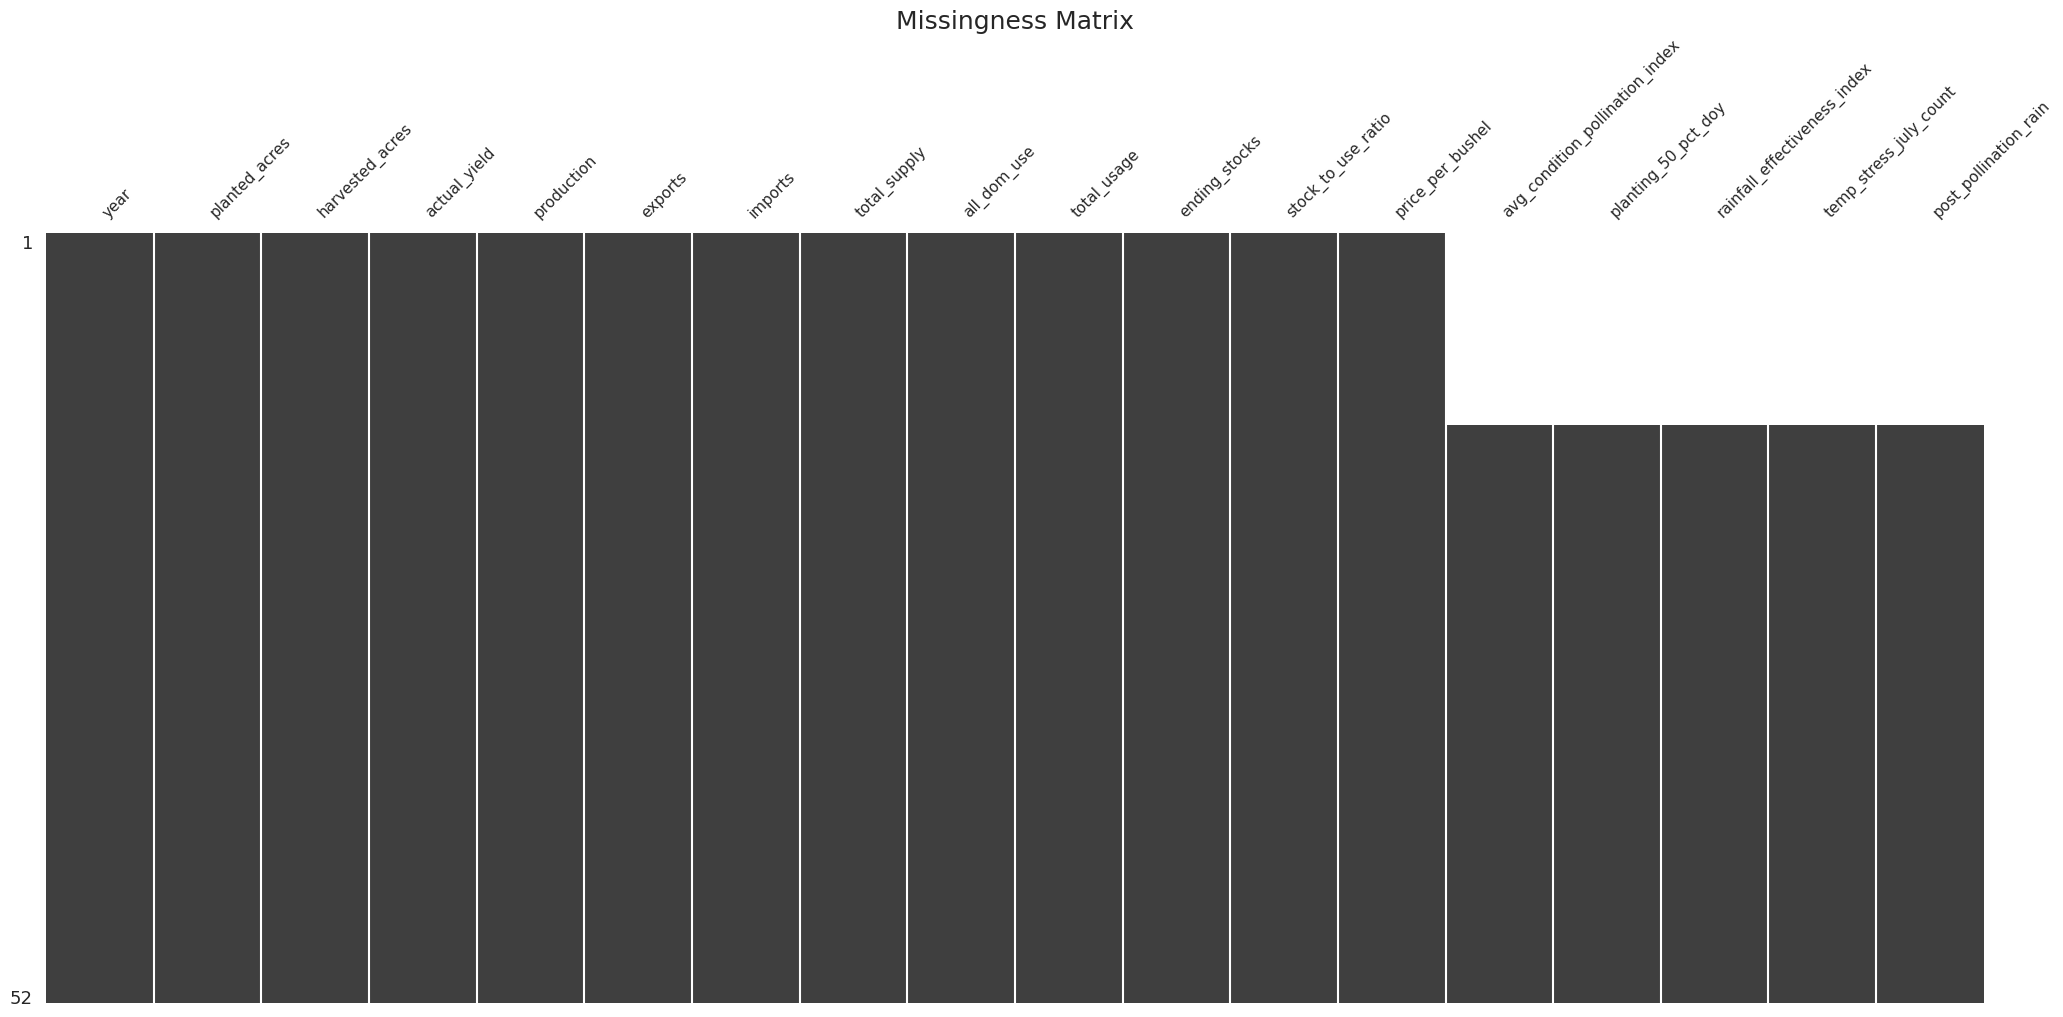

                                 missing_count missing_percent
rainfall_effectiveness_index                13           25.0%
planting_50_pct_doy                         13           25.0%
avg_condition_pollination_index             13           25.0%
post_pollination_rain                       13           25.0%
temp_stress_july_count                      13           25.0%
year                                         0            0.0%
planted_acres                                0            0.0%
harvested_acres                              0            0.0%
production                                   0            0.0%
actual_yield                                 0            0.0%
total_usage                                  0            0.0%
all_dom_use                                  0            0.0%
total_supply                                 0            0.0%
imports                                      0            0.0%
exports                                      0         

In [9]:
msno.matrix(df, sparkline=False, fontsize=11)
plt.title("Missingness Matrix", fontsize=18)
plt.show()

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values('missing_count', ascending=False)
missing_df['missing_percent'] = missing_df['missing_percent'].map(lambda x: f"{x:.1f}%")
print(missing_df)

### Data availability note (1973–1983)

The dataset contains some **missing values** for 1973–1983. This gap is due to crop progress reporting/data collection **not being available** during those years.


## EDA Utility Toolkit (Reusable Functions)

To keep the analysis readable and consistent, the next cell defines small utility functions that are reused across sections.  
They standardize how we summarize distributions, flag extreme years, quantify correlations (including controlling for time), and assess multicollinearity.

---

**What each helper does (quick reference):**
- `numeric_profile(df, cols)` → summary stats + skew/kurtosis for selected columns  
- `plot_hist_box(df, col)` → histogram + boxplot for one column  
- `top_bottom_years(df, col, n)` → top/bottom `n` years for a variable  
- `adf_kpss_table(df, cols)` → stationarity evidence table (ADF + KPSS)  
- `partial_corr_year(df, x, y)` → correlation between `x` and `y` after removing the linear effect of year  
- `add_era(df)` → adds a simple regime label (pre/post break year)  
- `corr_report(df, x, y)` → Pearson & Spearman correlations + p-values  
- `vif_table(df, features)` → VIF-based multicollinearity diagnostic




In [10]:
from typing import List, Dict, Optional

def numeric_profile(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """
    Create a compact numeric profiling table for selected columns.

    What it returns:
    - count, mean, std, min, quartiles, max
    - skew: distribution asymmetry (positive = right tail, negative = left tail)
    - kurtosis: tail heaviness (higher = heavier tails / more outliers)

    Notes:
    - Non-numeric values are coerced to NaN and dropped.
    - Columns with < 3 non-null observations are skipped.
    """
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(s) < 3:
            continue

        rows.append({
            "feature": col,
            "count": int(s.count()),
            "mean": float(s.mean()),
            "std": float(s.std()),
            "min": float(s.min()),
            "p25": float(s.quantile(0.25)),
            "median": float(s.median()),
            "p75": float(s.quantile(0.75)),
            "max": float(s.max()),
            "skew": float(s.skew()),
            "kurtosis": float(s.kurtosis()) })
    out = pd.DataFrame(rows).set_index("feature").sort_values("skew", ascending=False)
    return out


def plot_hist_box(df: pd.DataFrame, col: str, title: Optional[str] = None, bins: int = 15) -> None:
    """
    Plot a histogram and a boxplot side-by-side for a single column.

    What it shows:
    - Histogram: distribution shape (skewness, multi-modality)
    - Boxplot: outliers (points beyond 1.5×IQR) and spread

    Notes:
    - Non-numeric values are coerced to NaN and dropped.
    - If there are < 3 values after cleaning, the plot is skipped.
    """
    if col not in df.columns:
        print(f"⚠️ Column not found: {col}")
        return

    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(s) < 3:
        print(f"⚠️ Not enough data to plot {col}")
        return

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(s, bins=bins)
    ax[0].set_title(title or f"Histogram: {col}")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")
    ax[0].grid(True, alpha=0.3)
    ax[1].boxplot(s, vert=True)
    ax[1].set_title(f"Boxplot: {col}")
    ax[1].set_ylabel(col)
    ax[1].grid(True, alpha=0.3)

    plt.show()


def top_bottom_years(df: pd.DataFrame, col: str, n: int = 5) -> pd.DataFrame:
    """
    Return the top and bottom N years for a given column.

    Output:
    - year, column value, and a rank label: LOW or HIGH
    - LOW section is sorted ascending (smallest first)
    - HIGH section is sorted descending (largest first)

    Notes:
    - Requires 'year' and the target column to exist.
    - Drops rows with NaNs in either year or the target column.
    """
    if "year" not in df.columns:
        raise KeyError("DataFrame must contain a 'year' column.")
    if col not in df.columns:
        raise KeyError(f"Column not found: {col}")

    d = df[["year", col]].dropna().copy()
    d["year"] = d["year"].astype(int)

    low = d.sort_values(col, ascending=True).head(n).assign(rank="LOW")
    high = d.sort_values(col, ascending=False).head(n).assign(rank="HIGH")
    out = pd.concat([low, high], ignore_index=True)

    # Order output as LOW block then HIGH block
    out["rank_order"] = out["rank"].map({"LOW": 0, "HIGH": 1})
    out = out.sort_values(["rank_order", "rank"], ascending=[True, True])

    # Ensure within-block ordering is correct
    out_low = out[out["rank"] == "LOW"].sort_values(col, ascending=True)
    out_high = out[out["rank"] == "HIGH"].sort_values(col, ascending=False)

    return pd.concat([out_low, out_high]).drop(columns=["rank_order"], errors="ignore")


def adf_kpss_table(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """
    Build a stationarity evidence table using ADF and KPSS tests.

    Tests:
    - ADF (Augmented Dickey-Fuller): H0 = non-stationary (unit root)
      -> small p-value suggests stationarity
    - KPSS: H0 = stationary
      -> small p-value suggests non-stationarity

    Output columns:
    - adf_stat, adf_p
    - kpss_stat, kpss_p

    Notes:
    - Non-numeric values are coerced to NaN and dropped.
    - Series with < 10 observations are skipped.
    """
    rows = []
    for col in cols:
        if col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(s) < 10:
            continue

        adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")

        try:
            kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
        except Exception:
            kpss_stat, kpss_p = np.nan, np.nan

        rows.append({
            "series": col,
            "adf_stat": float(adf_stat),
            "adf_p": float(adf_p),
            "kpss_stat": float(kpss_stat) if pd.notna(kpss_stat) else np.nan,
            "kpss_p": float(kpss_p) if pd.notna(kpss_p) else np.nan })

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    return out.set_index("series").sort_values("adf_p")


def partial_corr_year(df: pd.DataFrame, x: str, y: str, year_col: str = "year") -> float:
    """
    Compute partial correlation between x and y after controlling for (removing) year.

    Method:
    - Regress x on year -> residuals rx
    - Regress y on year -> residuals ry
    - Return Pearson correlation between rx and ry

    Interpretation:
    - Helps distinguish whether x-y correlation is genuine or mostly driven by shared time trends.

    Notes:
    - Returns NaN if insufficient non-null observations (< 8).
    """
    for c in [year_col, x, y]:
        if c not in df.columns:
            raise KeyError(f"Missing required column: {c}")

    d = df[[year_col, x, y]].dropna().copy()
    if len(d) < 8:
        return np.nan

    X = sm.add_constant(d[year_col].astype(float))
    rx = sm.OLS(d[x].astype(float), X).fit().resid
    ry = sm.OLS(d[y].astype(float), X).fit().resid

    r, _ = stats.pearsonr(rx, ry)
    return float(r)


def add_era(df: pd.DataFrame, year_col: str = "year", break_year: int = 2007) -> pd.DataFrame:
    """
    Add a simple regime label column ('era') based on a break year.

    Output:
    - A copy of df with a new column:
      - 'Pre-Ethanol' for years < break_year
      - 'Post-Ethanol' for years >= break_year

    Notes:
    - This supports comparing relationships before vs after a known market regime shift.
    """
    if year_col not in df.columns:
        raise KeyError(f"Missing required column: {year_col}")

    out = df.copy()
    out["era"] = np.where(out[year_col].astype(float) < break_year, "Pre-Ethanol", "Post-Ethanol")
    return out


def corr_report(df: pd.DataFrame, x: str, y: str) -> Dict[str, float]:
    """
    Compute Pearson and Spearman correlations (with p-values) between two columns.

    Output keys:
    - pearson_r, pearson_p
    - spearman_r, spearman_p

    Notes:
    - Drops rows with NaNs in either x or y.
    - Returns NaNs if fewer than 5 valid pairs exist.
    """
    for c in [x, y]:
        if c not in df.columns:
            raise KeyError(f"Column not found: {c}")

    d = df[[x, y]].dropna()
    if len(d) < 5:
        return {"pearson_r": np.nan, "pearson_p": np.nan, "spearman_r": np.nan, "spearman_p": np.nan}

    pr, pp = stats.pearsonr(d[x], d[y])
    sr, sp = stats.spearmanr(d[x], d[y])

    return {
        "pearson_r": float(pr), "pearson_p": float(pp),
        "spearman_r": float(sr), "spearman_p": float(sp) }


def vif_table(df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
    """
    Compute Variance Inflation Factor (VIF) for a set of features.

    Purpose:
    - VIF quantifies multicollinearity. High VIF indicates a feature can be
      (approximately) predicted by other features, which can destabilize regression
      coefficients and inflate uncertainty.

    Output:
    - DataFrame with columns: feature, vif (sorted descending)

    Notes:
    - Drops rows with NaNs across the selected features.
    - Returns NaN VIFs if there are too few rows (< 10).
    """
    for f in features:
        if f not in df.columns:
            raise KeyError(f"Column not found: {f}")

    d = df[features].dropna().copy()
    if len(d) < 10:
        return pd.DataFrame({"feature": features, "vif": [np.nan] * len(features)})

    X = sm.add_constant(d.astype(float))
    vifs = []
    for i, f in enumerate(["const"] + features):
        if f == "const":
            continue
        vifs.append({"feature": f, "vif": float(variance_inflation_factor(X.values, i))})

    return pd.DataFrame(vifs).sort_values("vif", ascending=False)

## EDA Feature Layer (Derived columns for analysis only)

This section creates a small set of **analysis-only** variables used to interpret patterns more clearly:
- separate long-run yield improvements from year-to-year shocks
- summarize production disruption (abandonment)
- use a log transform for price to reduce the impact of extreme spikes

These columns do not replace the raw fields; they are added to support clearer interpretation in later plots and comparisons.



In [11]:
# 5-year rolling yield trend (simple technology adjustment)
df["yield_trend_roll5"] = df["actual_yield"].rolling(window=5, min_periods=1).mean()

# LOESS yield trend (captures longer-run non-linear improvements)
tmp = df[["year", "actual_yield"]].dropna().copy()
if len(tmp) >= 10:
    lo = lowess(tmp["actual_yield"], tmp["year"], frac=0.25, return_sorted=True)
    loess_map = dict(zip(lo[:, 0], lo[:, 1]))
    df["yield_trend"] = df["year"].map(loess_map)
else:
    df["yield_trend"] = np.nan

# Weather shock proxy: deviation from trend
df["yield_deviation"] = df["actual_yield"] - df["yield_trend"]

# Disaster proxy: abandonment rate (guard against division by 0)
df["abandonment_rate"] = np.where(
    df["planted_acres"].notna() & (df["planted_acres"] != 0),
    1.0 - (df["harvested_acres"] / df["planted_acres"]),
    np.nan )

# Log price (avoid log(0))
df["log_price"] = np.log(df["price_per_bushel"].clip(lower=1e-6))

df[["year", "actual_yield", "yield_trend", "yield_deviation", "abandonment_rate"]].tail()

,year,actual_yield,yield_trend,yield_deviation,abandonment_rate
47,2020,171.4,174.409545,-3.009545,0.092613
48,2021,176.7,175.089235,1.610765,0.085745
49,2022,173.4,175.770890,-2.370890,0.107710
50,2023,177.3,176.475221,0.824779,0.085624
51,2024,179.3,177.221955,2.078045,0.086909


**Interpretation check:**  
- The yield trend should appear smooth over time (capturing gradual improvements).  
- The yield deviation should fluctuate around zero, highlighting unusually good/bad years relative to the expected baseline.  
- Abandonment rate should be near zero in most years and rise in disruption years (e.g., extreme weather).  
- Log-price is used later to make visual comparisons more stable when there are price spikes.


### Missingness overview (after feature engineering)

After adding derived variables, we re-check missingness to ensure the new columns are well-defined across the time range and do not introduce systematic gaps that could affect later comparisons.




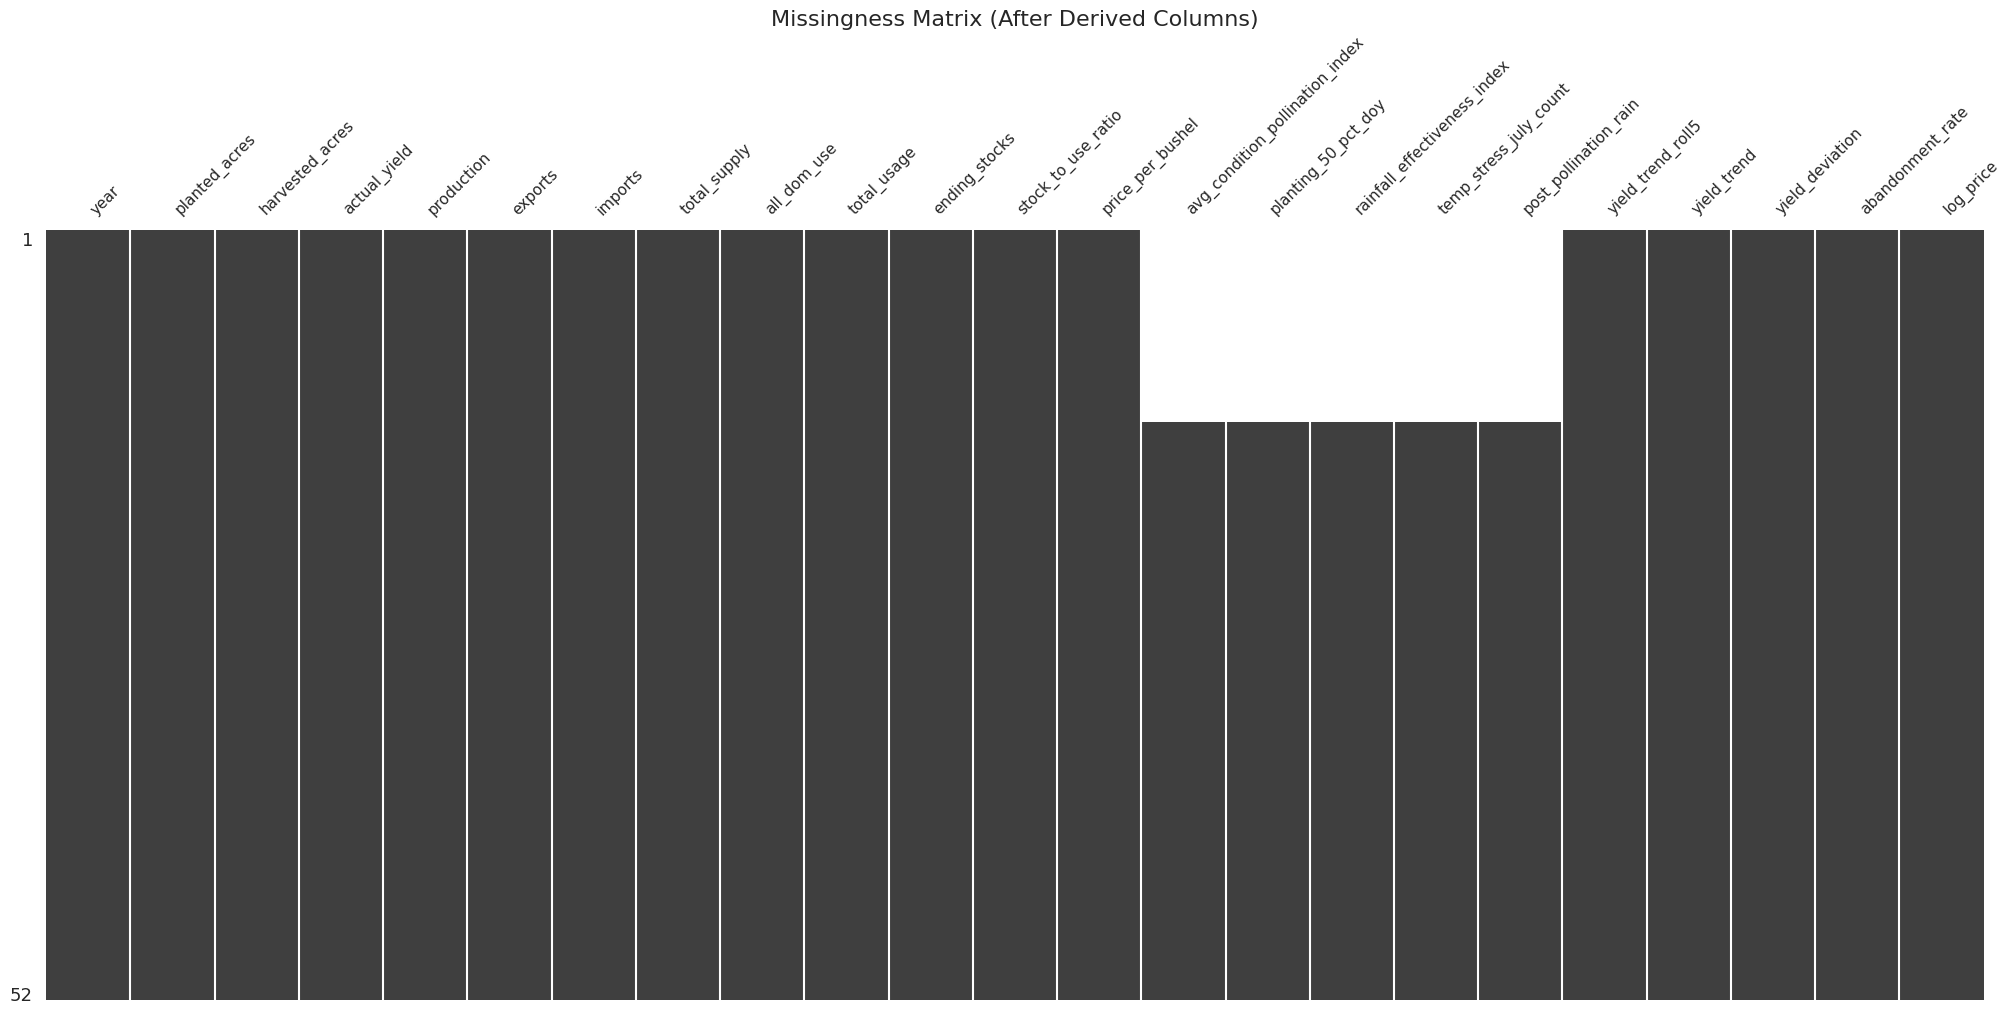

In [12]:
msno.matrix(df, sparkline=False, fontsize=11)
plt.title("Missingness Matrix (After Derived Columns)", fontsize=16)
plt.show()

## Statistical Profiling & Distribution Shape

This section characterizes the dataset numerically and visually:
- identify skewed / heavy-tailed variables
- spot extreme values that may represent rare events
- confirm derived variables behave sensibly

To keep the notebook readable, we **plot only a curated set of key analytical features** (the ones used in later relationship analysis).  
At the same time, we still compute a **full-table numeric profile** across all numeric columns to ensure nothing unusual is missed.

,count,mean,std,min,p25,median,p75,max,skew,kurtosis
feature,,,,,,,,,,
imports,52,18.115385,25.011099,1.000000,2.000000,11.500000,24.000000,160.000000,3.908719,20.253670
stock_to_use_ratio,52,0.183797,0.131528,0.049988,0.107741,0.146701,0.195904,0.661205,2.338727,5.489801
ending_stocks,52,1674.769231,886.740067,361.000000,1133.250000,1573.000000,1922.000000,4883.000000,1.767102,4.151232
price_per_bushel,52,2.977500,1.243396,1.470000,2.110000,2.510000,3.592500,7.010000,1.443216,1.988005
abandonment_rate,52,0.101898,0.022812,0.075855,0.085679,0.093790,0.110783,0.160775,1.147539,0.247011
log_price,52,1.019039,0.370495,0.385262,0.746551,0.920283,1.278848,1.947338,0.638797,-0.224276
temp_stress_july_count,39,27.477436,16.689294,0.160000,13.140000,25.140000,39.495000,69.940000,0.501200,-0.222092
total_usage,52,10009.750000,3079.496221,4826.000000,7359.250000,9447.500000,13057.750000,15145.000000,0.281278,-1.282957
all_dom_use,52,8108.480769,2922.240300,3677.000000,5387.750000,7447.500000,11119.750000,12711.000000,0.245790,-1.436415


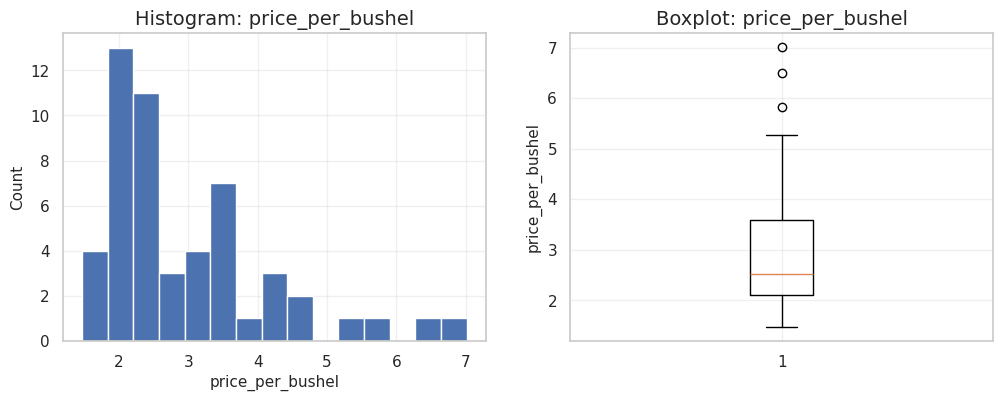

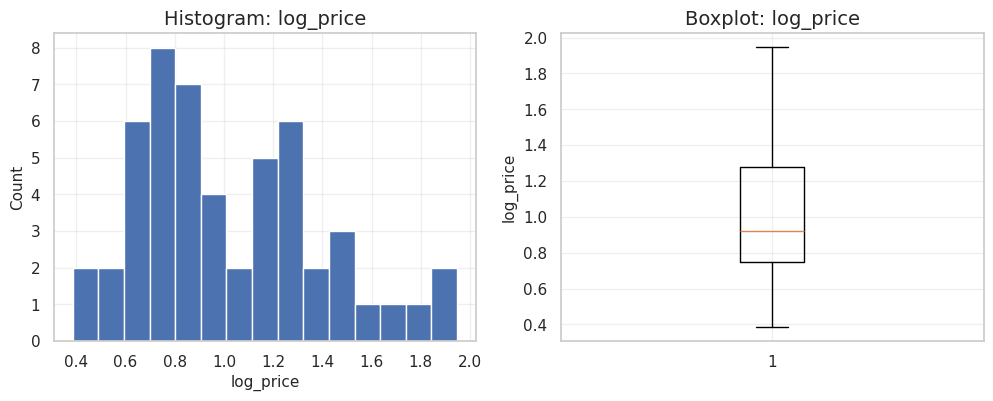

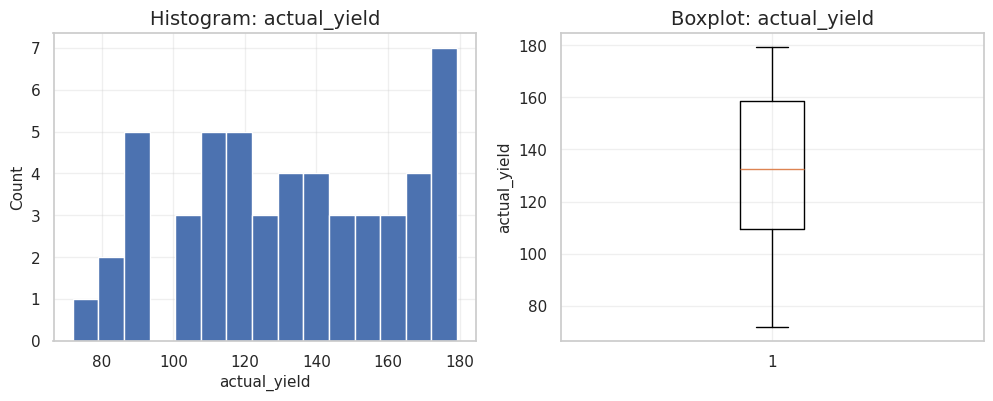

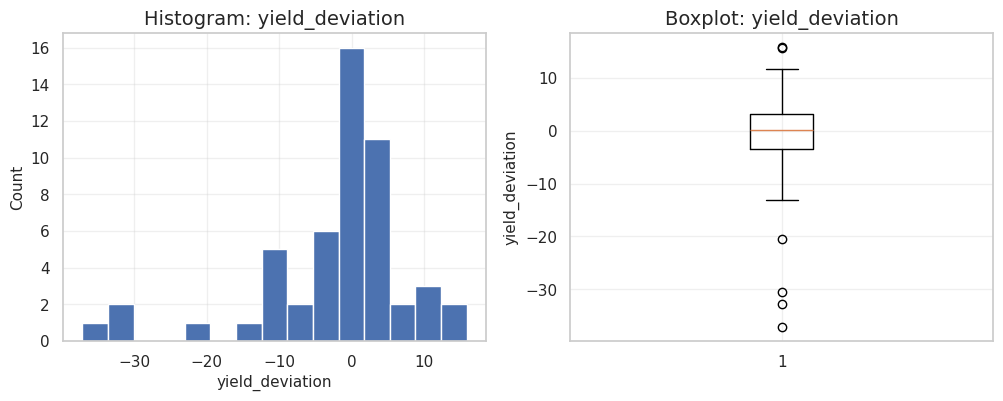

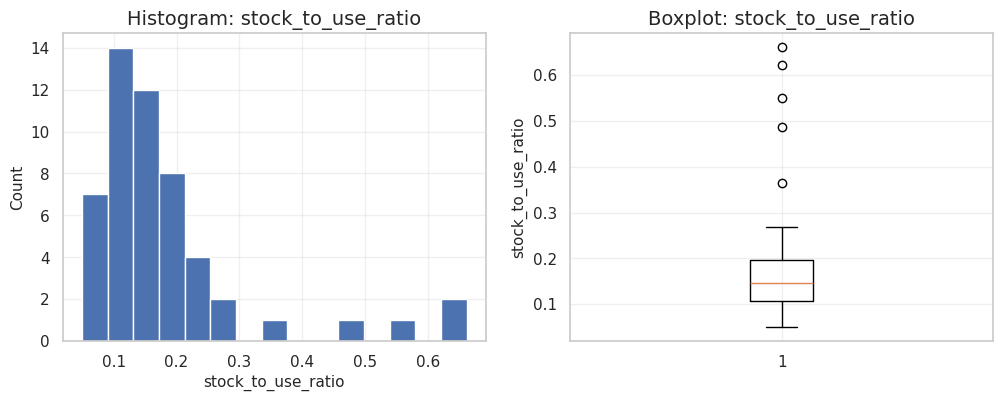

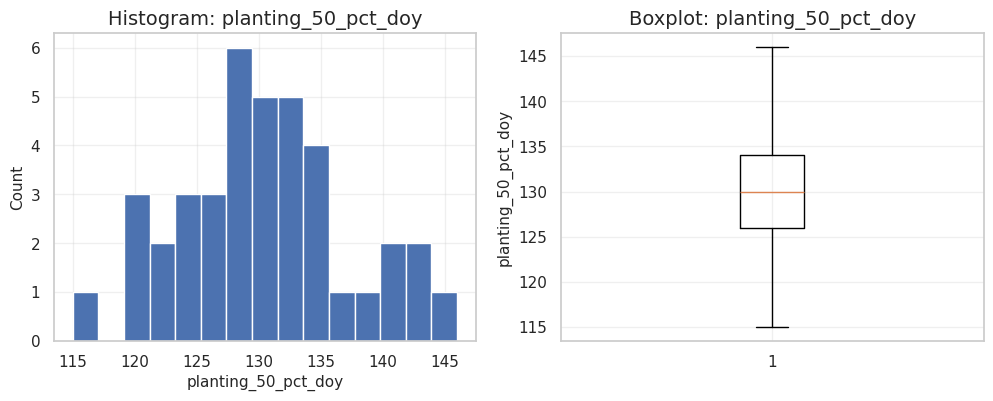

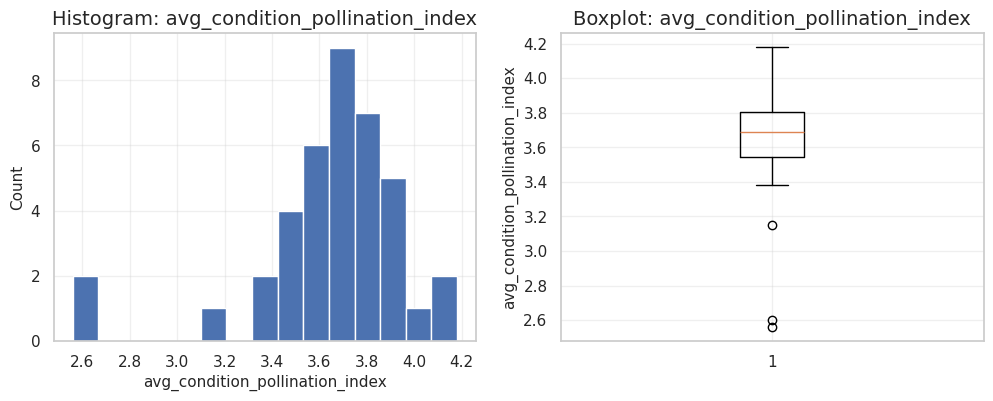

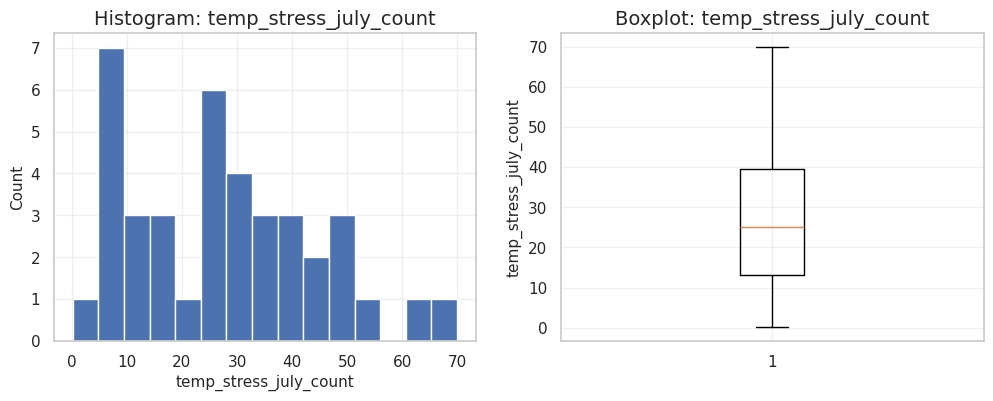

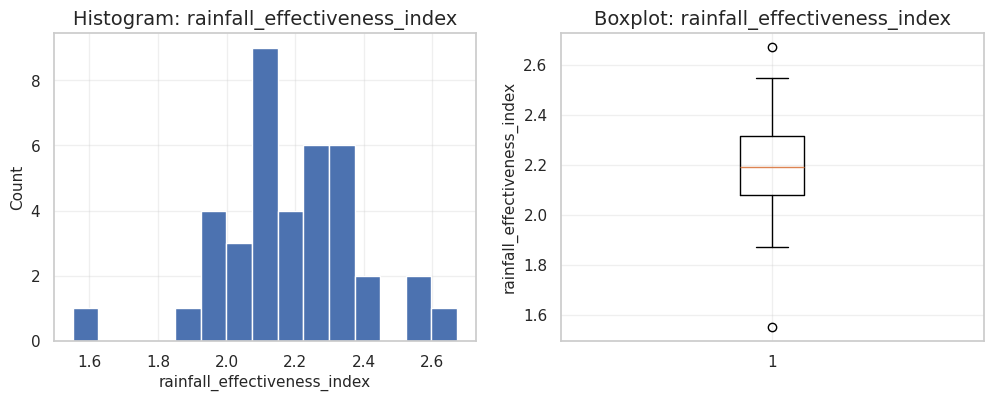

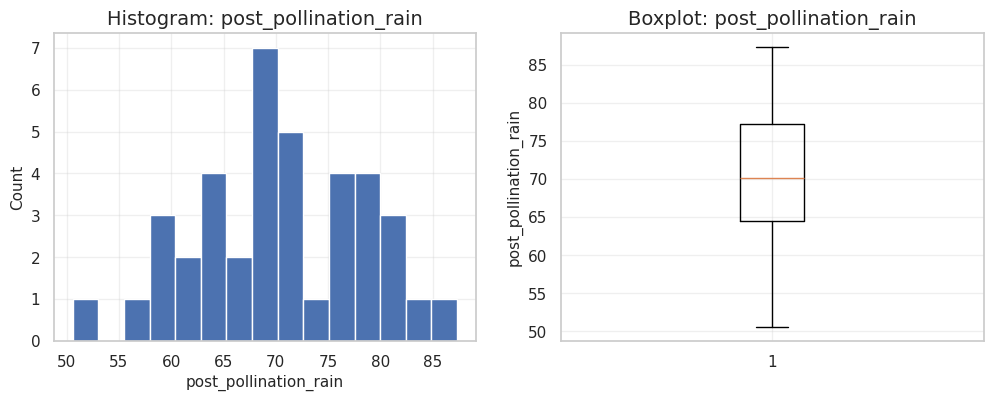

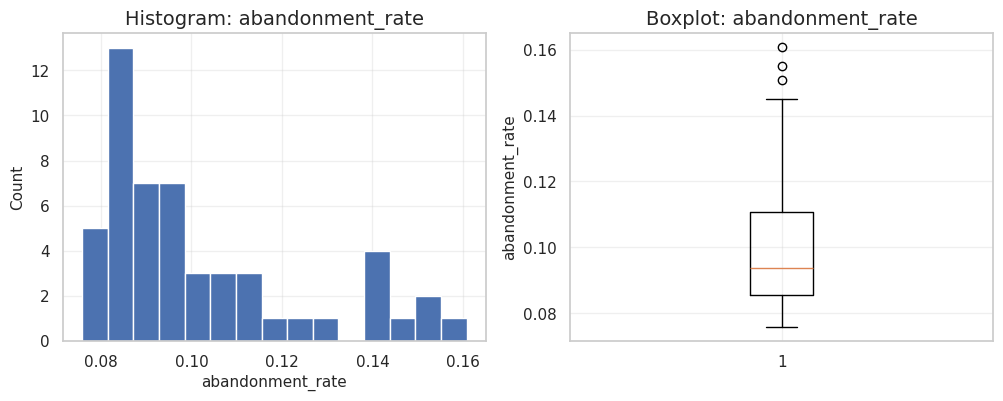

In [13]:
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
full_profile = numeric_profile(df, all_numeric)
display(full_profile)

# Plots only for key analytical features
FEATURES_FOR_PROFILE = [
    "price_per_bushel",
    "log_price",
    "actual_yield",
    "yield_deviation",
    "stock_to_use_ratio",
    "planting_50_pct_doy",
    "avg_condition_pollination_index",
    "temp_stress_july_count",
    "rainfall_effectiveness_index",
    "post_pollination_rain",
    "abandonment_rate" ]

FEATURES_FOR_PROFILE = [c for c in FEATURES_FOR_PROFILE if c in df.columns]

for c in FEATURES_FOR_PROFILE:
    plot_hist_box(df, c)

**Interpretation notes:**

- **Right-skew / heavy tails show up where we expect them.** The raw **price** distribution has a noticeable right tail with several high-end outliers in the boxplot, while **log_price** is visibly more compact and symmetric. This supports using the log transform later when we want stable comparisons that aren’t dominated by a few spike years.

- **Outliers look economically/agronomically plausible rather than “bad data.”** Several variables show clear boxplot outliers (notably **price_per_bushel**, **stock_to_use_ratio**, and **yield_deviation**). Given the historical presence of major drought and market-shock years in U.S. corn markets, these extremes are expected to carry real signal and should be retained.

- **Yield behavior matches the “trend + shock” structure.** **actual_yield** spans a wide range (consistent with both technology-driven improvement and weather variability). The **yield_deviation** distribution is centered near zero but is noticeably **left-skewed**, indicating occasional severe downside shocks (bad years) that pull yield below trend more strongly than good years push it above trend: exactly the behavior we want from a “weather shock proxy”.

- **Planting timing is tightly clustered, which is a good sign.** **planting_50_pct_doy** is concentrated in a relatively narrow band with limited outliers, consistent with planting occurring in a seasonal window. This suggests the derived timing metric is stable and not dominated by noise.

- **Crop condition and heat stress show meaningful variability.** The **avg_condition_pollination_index** is tightly distributed with a few low outliers (consistent with rare poor-condition years), while **temp_stress_july_count** spans a broad range with occasional extreme values, plausible for rare heat-wave years.

- **Rainfall effectiveness index** appears tightly concentrated with a small number of outliers on both ends. That shape is sensible for a ratio-style feature: most years cluster around a typical “effective rainfall per planting timing” level, while unusually early/late planting (or unusually wet/dry spring conditions) can generate rare high/low values. The limited spread is a good sign that the feature is stable rather than noisy.

- **Post-pollination rain** shows a broad but fairly smooth distribution without extreme tail behavior, which is consistent with seasonal rainfall totals over a fixed biological window. The boxplot suggests variability year-to-year (as expected), but not the kind of runaway spikes that would hint at unit problems.

- **Abandonment rate** is clearly **right-tailed**: most years sit near a low baseline, with a handful of higher outliers. That pattern is consistent with how abandonment behaves in reality (usually low, but rising in disruption years), and it supports using this variable as a “stress/disaster proxy” rather than treating those high values as errors.

- As already verified, **missingness is visible in some features.** A subset of variables shows fewer observations than the full year range. This means that later correlation/hypothesis analyses will implicitly use fewer years for those features, and we should keep that in mind when interpreting strength/significance.


## Outlier Detection — “Black Swan” Years

This section builds on the earlier spike-year diagnostic.  
Previously, we flagged years with unusually large **simultaneous** year-to-year changes and verified that several of them align with externally documented policy/climate shocks (e.g., early-1980s acreage shock, 1988 drought, 2012 drought, and the 2007 regime shift).

Here, we take a complementary view: instead of looking for synchronized jumps across many columns, we identify **extreme years for each key variable** (market, yield, stress indicators).  
If the same years recur as extremes across multiple variables, that strengthens the interpretation that they represent genuine “black swan” conditions rather than pipeline artifacts.

In [14]:
EXTREME_FEATURES = [
    "price_per_bushel",
    "stock_to_use_ratio",
    "yield_deviation",
    "avg_condition_pollination_index",
    "temp_stress_july_count",
    "rainfall_effectiveness_index",
    "post_pollination_rain",
    "abandonment_rate" ]
EXTREME_FEATURES = [c for c in EXTREME_FEATURES if c in df.columns]

# 1) Per-feature extremes (top/bottom years)
for c in EXTREME_FEATURES:
    print(f"\n=== Extremes for {c} ===")
    display(top_bottom_years(df, c, n=5))

# 2) Cross-feature "black swan" consensus: which years show up most often as extremes?
hits = []
for c in EXTREME_FEATURES:
    d = df[["year", c]].dropna().copy()
    d["year"] = d["year"].astype(int)

    low_years = d.sort_values(c, ascending=True).head(5)["year"].tolist()
    high_years = d.sort_values(c, ascending=False).head(5)["year"].tolist()

    hits += [(y, c, "LOW") for y in low_years]
    hits += [(y, c, "HIGH") for y in high_years]

hits_df = pd.DataFrame(hits, columns=["year", "feature", "tail"])

consensus = (
    hits_df.groupby("year")
           .size()
           .sort_values(ascending=False)
           .head(15)
           .to_frame("extreme_feature_hits"))

print("\nYears that appear most often among the extremes (cross-feature consensus):")
display(consensus)

# Variables that contributed for the top consensus years
top_years = consensus.index.tolist()
detail = hits_df[hits_df["year"].isin(top_years)].sort_values(["year", "tail", "feature"])
display(detail)


=== Extremes for price_per_bushel ===


,year,price_per_bushel,rank
0,1986,1.47,LOW
1,1987,1.61,LOW
2,1999,1.70,LOW
3,2005,1.77,LOW
4,2001,1.85,LOW
5,2012,7.01,HIGH
6,2022,6.49,HIGH
7,2011,5.83,HIGH
8,2021,5.26,HIGH
9,2023,4.66,HIGH



=== Extremes for stock_to_use_ratio ===


,year,stock_to_use_ratio,rank
0,1995,0.049988,LOW
1,2012,0.074077,LOW
2,1974,0.074803,LOW
3,2011,0.078943,LOW
4,1973,0.082090,LOW
5,1986,0.661205,HIGH
6,1985,0.621959,HIGH
7,1987,0.549052,HIGH
8,1982,0.486136,HIGH
9,1981,0.363728,HIGH



=== Extremes for yield_deviation ===


...


=== Extremes for abandonment_rate ===


,year,abandonment_rate,rank
0,2007,0.075855,LOW
1,2010,0.077098,LOW
2,2016,0.077234,LOW
3,1994,0.079419,LOW
4,2009,0.079861,LOW
5,1974,0.160775,HIGH
6,1976,0.154953,HIGH
7,1977,0.150768,HIGH
8,1983,0.145109,HIGH
9,1975,0.140972,HIGH



Years that appear most often among the extremes (cross-feature consensus):


,extreme_feature_hits
year,
2012,5
1986,4
1987,4
1992,4
1993,3
1994,3
1988,3
2002,3
2011,3


,year,feature,tail
35,1986,avg_condition_pollination_index,HIGH
15,1986,stock_to_use_ratio,HIGH
0,1986,price_per_bushel,LOW
54,1986,rainfall_effectiveness_index,LOW
37,1987,avg_condition_pollination_index,HIGH
17,1987,stock_to_use_ratio,HIGH
63,1987,post_pollination_rain,LOW
1,1987,price_per_bushel,LOW
30,1988,avg_condition_pollination_index,LOW
50,1988,rainfall_effectiveness_index,LOW


**Interpretation (extreme-year view + cross-feature consensus):**

- A small set of years repeatedly appears in the extreme tails across multiple variables. This is the key “black swan” signal: instead of isolated outliers in one series, the same years recur across *independent* market and climate/biological indicators, supporting the conclusion that these are genuine historical anomalies rather than pipeline artifacts.

- **2012 is the clearest multi-feature shock year.** It simultaneously shows extreme market behavior (high prices) and extreme agronomic stress/performance signatures (poor crop condition, high heat stress, low scarcity buffer, and strongly negative yield deviation). This coherent multi-variable alignment is exactly what we expect from a severe drought/heat shock year.

- The **1988 drought signal** also emerges across multiple features, notably as a “bad tail” year for yield deviation and crop condition, with supporting evidence from rainfall-related stress. Seeing the same year recur in both stress and outcome metrics is a strong plausibility check.

- The extreme-year outputs also capture **transition dynamics**, where years adjacent to major shocks can appear as extremes due to rebound or adjustment effects (e.g., shifts in price, stress indicators, or rainfall windows following a disruption year). This supports interpreting the dataset as reflecting real year-to-year market and biological transitions.

- Some extremes represent **favorable departures**, not only disasters (e.g., strong positive yield deviation, low heat stress, or unusually supportive rainfall in critical windows). This is useful because it shows the feature set distinguishes both negative and positive regimes rather than merely flagging “bad years”.

- The results highlight **distinct mechanisms and eras**:
  - **Stock-to-use** extremes concentrate in particular regimes (including early-1980s structural shifts and later scarcity periods), consistent with scarcity behaving as a regime-dependent and shock-dependent metric.
  - **Abandonment** extremes cluster in earlier decades and select disruption years, consistent with periods where acreage outcomes were more volatile and/or more sensitive to shocks.

- Finally, the directional alignment across features strengthens interpretability: “worse” agronomic indicators generally coincide with “tighter” market outcomes (e.g., higher prices). If a year appears extreme in only one variable, it becomes a targeted candidate for a quick definition/unit check; however, the most prominent years here recur across multiple features, which is the pattern we want.

## Trend, Regime, and Stationarity — the “Time” Factor

This section checks whether key variables drift over time. This matters because trend and regime shifts can create correlations that are driven by time rather than a direct relationship.

We use:
- rolling mean and a smooth trend to visualize long-run drift
- an era break marker to highlight potential regime shifts
- stationarity tests (ADF/KPSS) as evidence for non-stationary behavior

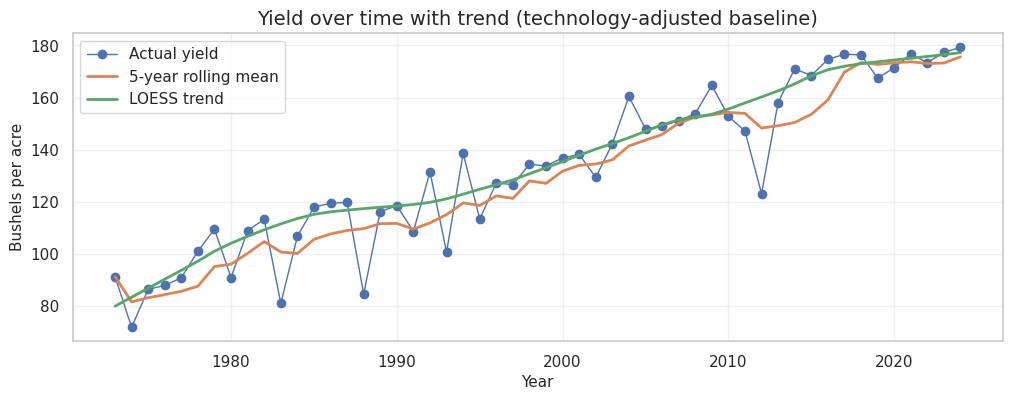

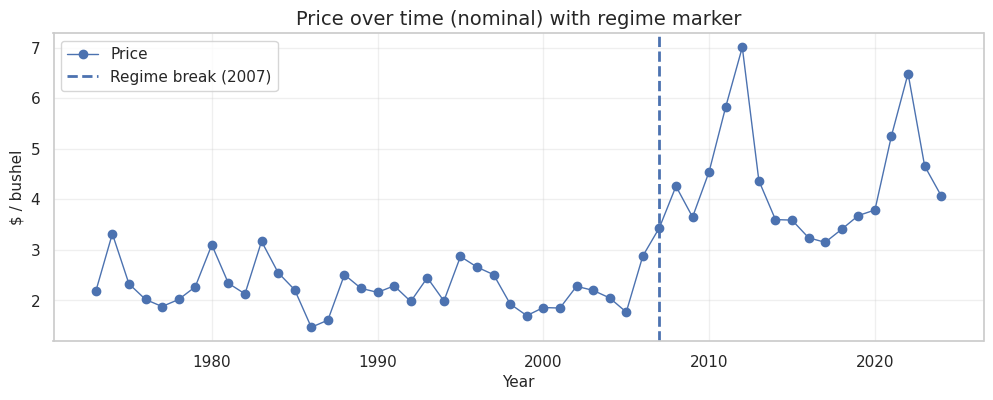

,adf_stat,adf_p,kpss_stat,kpss_p
series,,,,
yield_deviation,-8.035541,1.907168e-12,0.090798,0.100000
price_per_bushel,-2.262494,1.843499e-01,0.694252,0.014068
stock_to_use_ratio,-2.203770,2.048802e-01,0.447500,0.056681
log_price,-2.180241,2.134949e-01,0.706715,0.012935
actual_yield,-0.751798,8.328728e-01,1.126998,0.010000


In [15]:
df = df.sort_values("year").copy()

# Yield over time: actual vs rolling mean vs LOESS trend
plt.figure(figsize=(12, 4))
plt.plot(df["year"], df["actual_yield"], marker="o", linewidth=1, label="Actual yield")
plt.plot(df["year"], df["yield_trend_roll5"], linewidth=2, label="5-year rolling mean")
plt.plot(df["year"], df["yield_trend"], linewidth=2, label="LOESS trend")
plt.title("Yield over time with trend (technology-adjusted baseline)")
plt.xlabel("Year")
plt.ylabel("Bushels per acre")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Price over time: highlight regime break
BREAK_YEAR = 2007

plt.figure(figsize=(12, 4))
plt.plot(df["year"], df["price_per_bushel"], marker="o", linewidth=1, label="Price")
plt.axvline(BREAK_YEAR, linestyle="--", linewidth=2, label=f"Regime break ({BREAK_YEAR})")
plt.title("Price over time (nominal) with regime marker")
plt.xlabel("Year")
plt.ylabel("$ / bushel")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


SERIES_FOR_STATIONARITY = [
    "price_per_bushel",
    "log_price",
    "actual_yield",
    "yield_deviation",
    "stock_to_use_ratio" ]

SERIES_FOR_STATIONARITY = [c for c in SERIES_FOR_STATIONARITY if c in df.columns]
display(adf_kpss_table(df, SERIES_FOR_STATIONARITY))

**How to read the stationarity table (and what we observe here):**  
- **ADF** tests the null hypothesis that a series has a unit root (non-stationary). A small p-value is evidence **against** non-stationarity.  
- **KPSS** tests the null hypothesis that a series is stationary. A small p-value is evidence **against** stationarity.  

**Interpretation using the plots + table together:**  
- The **yield plot** shows a clear long-run upward drift, and the stationarity results are consistent with that: the yield series behaves as **time-dependent (non-stationary)**. This supports using **trend-adjusted yield** (i.e., `yield_deviation`) when we want to isolate weather-driven shocks rather than technology-driven improvements.  
- `yield_deviation` behaves much more like a **stationary shock series**: visually it represents departures from the smooth trend, and the tests provide evidence that it does not drift in the same way as raw yield. This makes it a better candidate for correlation analysis with climate stress variables.  
- The **price series** visibly changes character after the regime marker (larger swings and higher spikes), which is consistent with **regime effects** rather than a single stable distribution over the full period. The stationarity evidence supports treating price as **time-influenced**, motivating later checks that control for time (e.g., log transform, era splits, and partial correlation controlling for year).  
- Scarcity (`stock_to_use_ratio`) shows behavior that can be regime-driven and shock-driven (periods of tightness vs comfort), so it should be interpreted with the same caution as price: relationships may be partially driven by time/regime structure.

**Why this matters going forward:**  
If a variable trends or shifts by regime, correlations can be inflated by shared time structure. For that reason, later relationship checks will emphasize (i) **trend-adjusted variables** (like `yield_deviation`) and (ii) **time-aware correlation diagnostics** (such as partial correlation controlling for year and/or comparisons across eras).

**Important caveat:**  
- This is **annual data** with a relatively small sample, so **ADF/KPSS have limited power** (they may miss subtle non-stationarity or overreact to noise).   


## Hypothesis Validation — Feature Relationships vs Price

This section checks whether the engineered agronomic and climate features behave as expected when compared to harvest-time corn price. The goal is to validate that the final analytical table captures sensible relationships before moving to broader correlation and multicollinearity analysis.

We evaluate each hypothesis using three complementary views:
- **Pooled correlations (Pearson + Spearman):** quantify overall association across the full time range.
- **Partial correlation controlling for year:** reduces the risk that an apparent relationship is driven mainly by shared time trends or long-run regime shifts.
- **Era segmentation (pre-/post-2007):** checks whether relationships are stable across market regimes or change in strength/direction over time.

Together, these checks provide a structured “sanity validation” that the engineered features carry interpretable signal aligned with agronomic intuition.

,feature,target,expected_direction,pearson_r,pearson_p,spearman_r,spearman_p,partial_corr_r (control year),direction_match (pearson)
2,stock_to_use_ratio,price_per_bushel,Stock-to-use ↑ ⇒ Price ↓,-0.470975,0.000425,-0.680427,2.870987e-08,-0.282062,True
0,avg_condition_pollination_index,price_per_bushel,Condition ↑ ⇒ Price ↓,-0.341625,0.033292,-0.312915,5.242943e-02,-0.432670,True
1,rainfall_effectiveness_index,price_per_bushel,Rain effectiveness ↑ ⇒ Price ↓,-0.026782,0.871430,0.005871,9.717048e-01,-0.197205,True
3,temp_stress_july_count,price_per_bushel,Heat stress ↑ ⇒ Price ↑,0.411046,0.009336,0.280176,8.406673e-02,0.223478,True


,era,feature,n,pearson_r,spearman_r
1,Post-Ethanol,avg_condition_pollination_index,18,-0.685702,-0.502580
0,Pre-Ethanol,avg_condition_pollination_index,21,-0.468679,-0.507147
3,Post-Ethanol,rainfall_effectiveness_index,18,-0.406557,-0.413829
2,Pre-Ethanol,rainfall_effectiveness_index,21,0.067105,0.161091
5,Post-Ethanol,stock_to_use_ratio,18,-0.734999,-0.803922
4,Pre-Ethanol,stock_to_use_ratio,34,-0.451984,-0.454768
7,Post-Ethanol,temp_stress_july_count,18,0.562929,0.320949
6,Pre-Ethanol,temp_stress_july_count,21,0.175027,0.040922


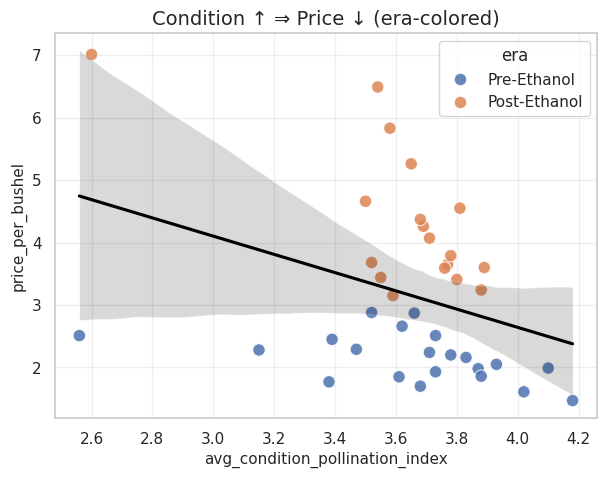

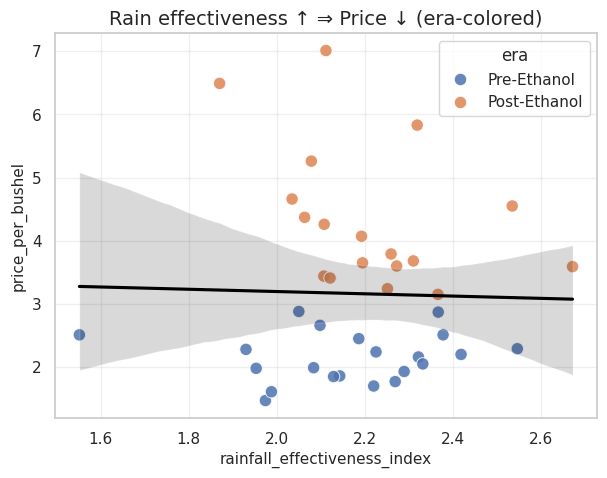

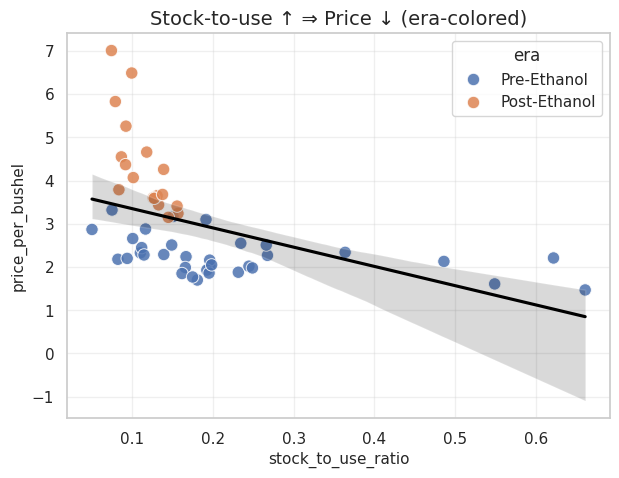

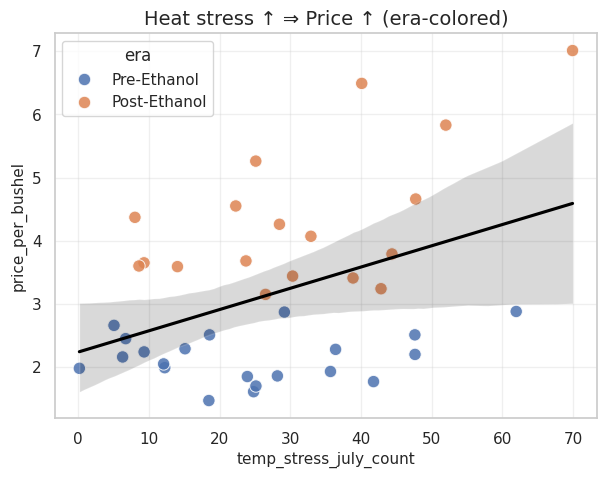

In [16]:
TARGET = "price_per_bushel"

HYPOTHESES = [
    ("avg_condition_pollination_index", TARGET, "Condition ↑ ⇒ Price ↓", -1),
    ("rainfall_effectiveness_index", TARGET, "Rain effectiveness ↑ ⇒ Price ↓", -1),
    ("stock_to_use_ratio", TARGET, "Stock-to-use ↑ ⇒ Price ↓", -1),
    ("temp_stress_july_count", TARGET, "Heat stress ↑ ⇒ Price ↑", +1) ]

# Keep only valid pairs
HYPOTHESES = [(x, y, d, sgn) for (x, y, d, sgn) in HYPOTHESES if x in df.columns and y in df.columns]

# Pooled correlation summary table
rows = []
for x, y, desc, expected_sign in HYPOTHESES:
    rep = corr_report(df, x, y)
    pc = partial_corr_year(df, x, y)

    # Determine if observed Pearson sign matches expected direction (ignoring NaNs)
    sign_match = np.nan
    if pd.notna(rep["pearson_r"]):
        sign_match = (np.sign(rep["pearson_r"]) == np.sign(expected_sign))

    rows.append({
        "feature": x,
        "target": y,
        "expected_direction": desc,
        "pearson_r": rep["pearson_r"],
        "pearson_p": rep["pearson_p"],
        "spearman_r": rep["spearman_r"],
        "spearman_p": rep["spearman_p"],
        "partial_corr_r (control year)": pc,
        "direction_match (pearson)": sign_match })

corr_tbl = pd.DataFrame(rows).sort_values("pearson_r")
display(corr_tbl)


df_e = add_era(df, break_year=2007)
era_rows = []
for x, y, desc, expected_sign in HYPOTHESES:
    for era in ["Pre-Ethanol", "Post-Ethanol"]:
        sub = df_e[df_e["era"] == era][[x, y]].dropna()
        rep = corr_report(sub, x, y)
        era_rows.append({
            "era": era,
            "feature": x,
            "n": len(sub),
            "pearson_r": rep["pearson_r"],
            "spearman_r": rep["spearman_r"] })

era_tbl = pd.DataFrame(era_rows).sort_values(["feature", "era"])
display(era_tbl)

# Era-colored scatter plots
for x, y, desc, expected_sign in HYPOTHESES:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df_e, x=x, y=y, hue="era", s=80, alpha=0.85)
    sns.regplot(data=df_e, x=x, y=y, scatter=False, color="black")  # pooled linear fit
    plt.title(f"{desc} (era-colored)")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    plt.show()

### Interpretation of hypothesis plots (era-colored)

- **Regime separation is visually clear.** Across all plots, points in the post-2007 era generally sit at higher price levels than the pre-2007 era, consistent with a market regime shift. This justifies checking relationships both pooled and within-era, and it motivates time-aware correlation (e.g., partial correlation controlling for year).

- **Stock-to-use ratio vs price:** The relationship is strongly **negative** with a clear downward fitted line. This matches the economic scarcity intuition: more supply buffer (higher stock-to-use) is associated with lower price. The separation between eras suggests the *baseline price level* changes by regime, but the scarcity signal remains interpretable across the full sample.

- **Heat stress vs price:** The relationship is **positive** with an upward fitted line, aligning with the biological mechanism: more extreme heat stress during critical growth stages is associated with reduced yield potential and therefore higher prices. Post-2007 observations occupy higher price levels, but the positive slope indicates the stress–price linkage remains visible even when accounting for regime differences.

- **Rainfall effectiveness vs price:** The fitted line appears **weak/near-flat** in the pooled view, suggesting a smaller or noisier marginal relationship at the national annual scale. This does not invalidate the feature; it can indicate that (i) rainfall effects are non-linear, (ii) other factors (stocks, demand, technology) dominate price variation, or (iii) the relationship is stronger when conditioning on other variables (e.g., heat stress, crop condition) rather than in a single-variable scatter.

- **Overall validation:** The strongest “sanity-confirming” signals are the expected scarcity and heat-stress relationships (stock-to-use ↓ price, heat stress ↑ price). The weaker rainfall-effectiveness slope highlights why later analysis should include multi-variable correlation structure (correlation matrix/VIF) and time-aware diagnostics rather than relying on a single bivariate plot.


## Correlation Structure & Multicollinearity

We now examine how the features relate to each other as a group. This serves two purposes:
- identify which features are most associated with harvest-time price,
- detect multicollinearity (features that mostly duplicate each other), which can distort interpretation and later modeling.

We use:
- a correlation heatmap (global view),
- VIF (Variance Inflation Factor) to quantify redundancy among predictors.


To keep interpretation simple, we use **price in levels** (not log-price) in the matrix, and we plot only the lower triangle to reduce redundancy.


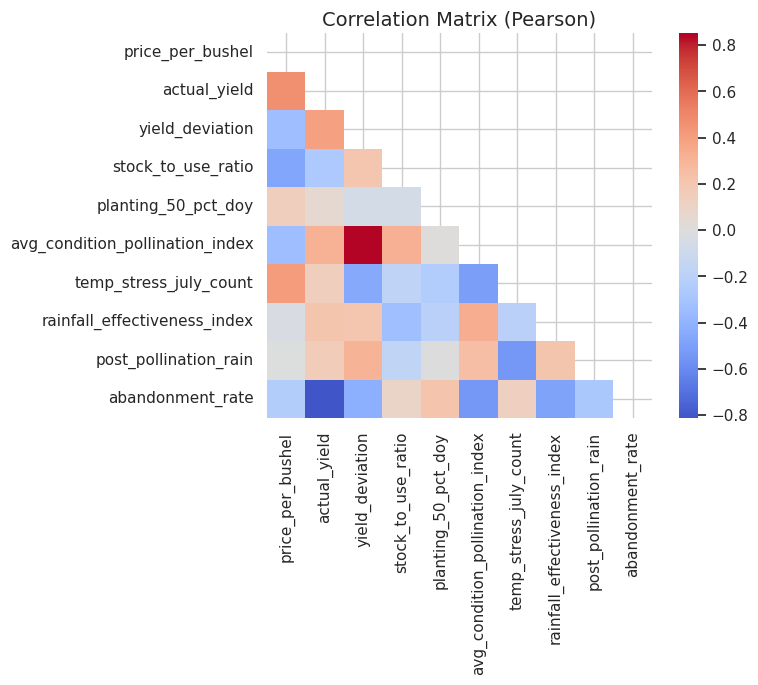

In [17]:
FEATURES_FOR_CORR = [
    "price_per_bushel",
    "actual_yield",
    "yield_deviation",
    "stock_to_use_ratio",
    "planting_50_pct_doy",
    "avg_condition_pollination_index",
    "temp_stress_july_count",
    "rainfall_effectiveness_index",
    "post_pollination_rain",
    "abandonment_rate" ]
FEATURES_FOR_CORR = [c for c in FEATURES_FOR_CORR if c in df.columns]

corr_mat = df[FEATURES_FOR_CORR].corr(method="pearson")

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
plt.figure(figsize=(7, 5))
sns.heatmap(corr_mat, mask=mask, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix (Pearson)")
plt.show()

In [18]:
# VIF computed on predictors only (exclude the target)
PREDICTORS = [
    "yield_deviation",
    "stock_to_use_ratio",
    "planting_50_pct_doy",
    "avg_condition_pollination_index",
    "temp_stress_july_count",
    "rainfall_effectiveness_index",
    "post_pollination_rain",
    "abandonment_rate" ]
PREDICTORS = [c for c in PREDICTORS if c in df.columns]

vif = vif_table(df, PREDICTORS)
display(vif)

,feature,vif
3,avg_condition_pollination_index,6.093666
0,yield_deviation,5.378287
7,abandonment_rate,2.539480
4,temp_stress_july_count,2.393219
5,rainfall_effectiveness_index,2.164353
1,stock_to_use_ratio,2.078588
6,post_pollination_rain,1.745110
2,planting_50_pct_doy,1.396371


### Interpretation: correlation structure + multicollinearity

**Correlation heatmap:**
- The strongest visible relationships involving **price** align with the earlier hypothesis plots: price tends to move **oppositely to “supply buffer / performance” signals** (e.g., scarcity proxies and yield-based signals) and **with stress signals** (e.g., heat stress). This consistency across sections supports that the feature engineering produced interpretable signals rather than arbitrary noise.
- Several predictors show mild-to-moderate correlations with each other (expected in an agricultural system where weather, crop condition, and yield outcomes are linked), but the matrix does not suggest that *all* engineered features collapse into a single redundant block.

**VIF table (multicollinearity evidence):**
- Most predictors have **low-to-moderate VIF**, indicating limited redundancy and supporting the idea that they capture distinct aspects of the system (timing, stress, moisture, scarcity, and yield shocks).
- Two features stand out with **elevated VIF**: `avg_condition_pollination_index` and `yield_deviation`. This is plausible because crop condition is intrinsically related to yield outcomes (good condition tends to coincide with above-trend yield, poor condition with below-trend yield). In other words, these variables partially share information by design.
- Practically, this means we should be cautious about interpreting these two predictors as fully independent “separate causes” in any later multivariate model. However, elevated VIF here does **not** invalidate them, rather, it documents that the biological pathway (condition → yield) creates natural overlap.

**Conclusion:**  
The correlation matrix and VIF results indicate a healthy feature set: relationships with price are directionally coherent, and multicollinearity is mostly manageable, with the main overlap appearing where agronomic logic suggests it should (condition and yield-shock measures).


# Summary of EDA Findings

- **Data readiness:** The final analytical table behaves consistently at the yearly grain: one row per year, numeric types throughout, and missingness patterns are visible and explainable (rather than random-looking join failures).

- **Distribution / outliers:** Several variables are heavy-tailed with meaningful extremes (notably price, scarcity, and yield shocks). These outliers are treated as informative “shock years” rather than errors unless contradicted by source definitions.

- **Black swan years recur across features:** Extreme-year checks highlight recurring shock periods, with **2012** standing out as a multi-feature event (market + biological stress alignment) and **1988** also appearing as a strong adverse agronomic year. This cross-feature agreement increases confidence that the pipeline preserved historically meaningful anomalies.

- **Time matters (trend + regime):** Yield shows a clear long-run upward drift, and price exhibits regime-like behavior with larger swings after the regime marker. This motivates using trend-adjusted variables (e.g., `yield_deviation`) and time-aware association checks rather than assuming stability across decades.

- **Hypothesis validation:** Scarcity and stress features show directionally coherent relationships with price (e.g., stock-to-use behaving as an inverse price signal; heat stress behaving as a positive price pressure). Some relationships (e.g., rainfall effectiveness) appear weaker in simple bivariate views, suggesting non-linearity or interaction effects.

- **Multicollinearity:** Most predictors show manageable redundancy. The strongest overlap appears where agronomic logic suggests it should (crop condition and yield-shock measures), so later interpretation/modeling should treat these as partially overlapping signals rather than independent drivers.

**Implication:** The engineered feature set is consistent, interpretable, and suitable for downstream modeling. Any next-step modeling should account for time structure (trend/regimes), treat shock years as signal, and be mindful of overlapping agronomic predictors.
